In [2]:
import os

os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
from functools import partial

# pip install -e.
import jax
import pandas
from jax import numpy as jnp
from jax import random
from collections import namedtuple

from time import perf_counter
from bartz.BART import gbart
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

## Date Pre-Processing

In [3]:
outcomes = pandas.read_csv('./data/NHANES_outcomes.csv')
predictors = pandas.read_csv('./data/NHANES_predictors.csv')
outcomes_names = outcomes.columns.tolist()
X_full_raw = predictors.values
y_full_raw = outcomes.values

y_full = y_full_raw / jnp.std(y_full_raw, axis=0)
Z = X_full_raw[:, [0]]               # shape (n, 1) — treatment
X_covariates = X_full_raw[:, 1:4]    # use columns 2 to 4 

In [4]:
key = random.key(42)
n_total = X_covariates.shape[0]
train_frac = 0.7
n_train = int(train_frac * n_total)

# Create random permutation
perm = random.permutation(key, n_total)
train_idx = perm[:n_train]
test_idx = perm[n_train:]

X_train = X_covariates[train_idx, :]
X_test = X_covariates[test_idx, :]
X_train_with_z = X_full_raw[train_idx, :]
X_test_with_z = X_full_raw[test_idx, :]

y_train = y_full[train_idx, :]
y_test = y_full[test_idx, :]
Z_train = Z[train_idx, :].astype(jnp.float32)
Z_test = Z[test_idx, :].astype(jnp.float32)

In [5]:
ps_model = LogisticRegression(solver='liblinear', random_state=42)
ps_model.fit(X_train, Z_train)
ps_train = ps_model.predict_proba(X_train)[:, 1]
ps_test = ps_model.predict_proba(X_test)[:, 1]

X_train_ps = jnp.concatenate([X_train, ps_train[:, None]], axis=1)
X_test_ps = jnp.concatenate([X_test, ps_test[:, None]], axis=1)


print(f"Final covariate matrix shape (with ps): {X_train_ps.shape}")

# 7. Put into namedtuple (transposed for gbart)
Data = namedtuple('Data', 'X_train X_train_with_ps X_train_with_z y_train X_test X_test_with_ps X_test_with_z y_test Z_train Z_test ps_train ps_test')
data = Data(
    X_train=X_train.T,
    X_train_with_ps=X_train_ps.T,
    X_train_with_z = X_train_with_z.T,
    X_test=X_test.T,
    X_test_with_ps=X_test_ps.T,
    X_test_with_z = X_test_with_z.T,
    y_train=y_train,
    y_test=y_test,
    Z_train=Z_train,
    Z_test=Z_test,
    ps_train=ps_train,
    ps_test=ps_test
)

device = jax.devices()[0]
data = jax.device_put(data, device)

print("Data loaded, standardized, split, and sent to device.")

Final covariate matrix shape (with ps): (1007, 4)
Data loaded, standardized, split, and sent to device.


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [6]:
n_tree = 200  # number of trees used by bartz

keys = list(random.split(random.key(202404161853), 2))
# run bartz
start = perf_counter()
mvbart = gbart(
    data.X_train_with_z,
    data.y_train,
    ntree=n_tree,
    nskip=1000,
    ndpost=3000,
    printevery=100,
    seed=keys.pop(),
)

end = perf_counter()

/opt/conda/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:5721: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  return array(a, dtype=dtype, copy=bool(copy), order=order, device=device)


....................................................................................................
Iteration 100/4000, grow prob: 78%, move acc: 10%, fill: 8% (burnin)
....................................................................................................
Iteration 200/4000, grow prob: 64%, move acc: 9%, fill: 14% (burnin)
....................................................................................................
Iteration 300/4000, grow prob: 63%, move acc: 7%, fill: 19% (burnin)
....................................................................................................
Iteration 400/4000, grow prob: 61%, move acc: 9%, fill: 24% (burnin)
....................................................................................................
Iteration 500/4000, grow prob: 57%, move acc: 6%, fill: 27% (burnin)
....................................................................................................
Iteration 600/4000, grow prob: 51%, move acc: 6%,

In [7]:
# compute predictions
yhat_test = mvbart.predict(data.X_test_with_z)  # posterior samples, n_samples x n_test
yhat_test_mean = jnp.mean(yhat_test, axis=0)  # posterior mean point-by-point
yhat_test_var = jnp.var(yhat_test, axis=0)  # posterior variance point-by-point

# Covariance matrix
sigam2_cov = mvbart.sigma2_cov_mean
sigma2_cov_prec = mvbart.sigma2_cov_prec_mean
# print('yhat_test_mean is, ', yhat_test_mean)
print('covariance matrix inverse is, ', sigma2_cov_prec)
cov_matrix_afterbart = jnp.linalg.inv(sigma2_cov_prec)
std_devs = jnp.sqrt(jnp.diag(cov_matrix_afterbart))
corr_matrix_afterbart = cov_matrix_afterbart / jnp.outer(std_devs, std_devs)
print('corr_matrix_afterbart', corr_matrix_afterbart)

covariance matrix inverse is,  [[ 1.8179821  -0.13804153  0.08583637  0.09621812  0.01456591 -0.3189933
  -0.11756498 -0.15837394  0.93246335 -0.02758011]
 [-0.13804153  1.0630983  -0.03998132  0.05617907 -0.03567104 -0.07369002
  -0.12086165 -0.05074933 -0.01175711  0.01952145]
 [ 0.08583637 -0.03998132  1.1875267  -0.09758876  0.27472317  0.0636986
   0.11327901  0.19600785 -0.2659123   0.03491387]
 [ 0.09621812  0.05617907 -0.09758876  1.2198998  -0.19213077 -0.00261572
   0.00871985  0.01945366  0.0591793   0.0411749 ]
 [ 0.01456591 -0.03567104  0.27472317 -0.19213077  1.1528089   0.00859738
   0.03456981  0.17235844 -0.01051081  0.08173469]
 [-0.3189933  -0.07369002  0.0636986  -0.00261572  0.00859738  1.1982335
   0.00759156  0.0283515  -0.24805462  0.0240046 ]
 [-0.11756498 -0.12086165  0.11327901  0.00871985  0.03456981  0.00759156
   1.8058115  -0.0469783  -0.02852657 -0.51225555]
 [-0.15837394 -0.05074933  0.19600785  0.01945366  0.17235844  0.0283515
  -0.0469783   1.2979221

In [8]:
X_test_treated = jnp.concatenate([jnp.ones((data.ps_test.shape[0], 1)).T, data.X_test], axis=0)
X_test_control = jnp.concatenate([jnp.zeros((data.ps_test.shape[0], 1)).T, data.X_test], axis=0)

# print('X_test_treated is now:', X_test_treated)
ate_test = mvbart.predict(X_test_treated) - mvbart.predict(X_test_control) # (3000, 432, 10)


ate_test_mean = jnp.mean(ate_test, axis=0) # (432, 10)
ate_ci_lo, ate_ci_hi = jnp.quantile(jnp.mean(ate_test, axis=1), jnp.array([0.025, 0.975]))
ate_test_var = jnp.var(ate_test, axis=0)

rmse_per_col = jnp.sqrt(jnp.mean(jnp.square(yhat_test_mean - data.y_test), axis=0))
ate_draws = jnp.mean(ate_test, axis=1)  # (n_draws, n_outcomes)
for i, col_name in enumerate(outcomes_names):
    draws_i = ate_draws[:, i]
    ate_mean = jnp.mean(draws_i)
    ci_lo, ci_hi = jnp.quantile(draws_i, jnp.array([0.025, 0.975]))
    rmse = rmse_per_col[i]
    
    print(f"{col_name:15s} | ATE: {ate_mean:.4f} (CI: {ci_lo:.4f}, {ci_hi:.4f}) | RMSE: {rmse:.4f}")
print(f'Total RMSE: {rmse:#.2g}')

HDL             | ATE: 0.4275 (CI: 0.1916, 0.6715) | RMSE: 0.9336
Methylmercury   | ATE: 0.2341 (CI: 0.0177, 0.4587) | RMSE: 0.9293
Glucose         | ATE: -0.1163 (CI: -0.3565, 0.1135) | RMSE: 0.8059
Potassium       | ATE: 0.1930 (CI: -0.0290, 0.4242) | RMSE: 1.0417
Sodium          | ATE: -0.1594 (CI: -0.3883, 0.0777) | RMSE: 0.9947
Iron            | ATE: 0.2024 (CI: -0.0332, 0.4348) | RMSE: 0.9493
Lead            | ATE: 0.4031 (CI: 0.1956, 0.6270) | RMSE: 0.8726
LDL             | ATE: 0.0699 (CI: -0.1770, 0.3104) | RMSE: 1.0160
Triglycerides   | ATE: 0.0369 (CI: -0.1667, 0.2456) | RMSE: 0.9909
Cadmium         | ATE: -0.0391 (CI: -0.2545, 0.1709) | RMSE: 0.9527
Total RMSE: 0.95


In [9]:
len(jnp.mean(ate_draws, axis=0))

10

In [10]:
import pandas as pd

y_full_raw = pd.DataFrame(y_full_raw)
corr_matrix_y = y_full_raw.corr()
corr_matrix_y

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.120573,-0.191282,-0.106028,0.005250,0.077813,0.067175,-0.034536,-0.495399,0.119813
1,0.120573,1.000000,0.030897,-0.019947,0.040133,0.144053,0.169842,0.076546,-0.004075,0.055030
2,-0.191282,0.030897,1.000000,0.083350,-0.120794,0.012498,0.081257,-0.084917,0.275061,-0.017379
3,-0.106028,-0.019947,0.083350,1.000000,0.143993,0.073836,0.066108,-0.058401,0.032563,-0.089086
4,0.005250,0.040133,-0.120794,0.143993,1.000000,0.031452,0.032057,-0.085410,-0.044323,-0.017072
5,0.077813,0.144053,0.012498,0.073836,0.031452,1.000000,0.116816,0.042756,0.097184,-0.037787
6,0.067175,0.169842,0.081257,0.066108,0.032057,0.116816,1.000000,0.071316,0.097189,0.346397
7,-0.034536,0.076546,-0.084917,-0.058401,-0.085410,0.042756,0.071316,1.000000,0.289047,-0.010522
8,-0.495399,-0.004075,0.275061,0.032563,-0.044323,0.097184,0.097189,0.289047,1.000000,-0.021220
9,0.119813,0.055030,-0.017379,-0.089086,-0.017072,-0.037787,0.346397,-0.010522,-0.021220,1.000000


## Some Visualization

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Correlation Plot

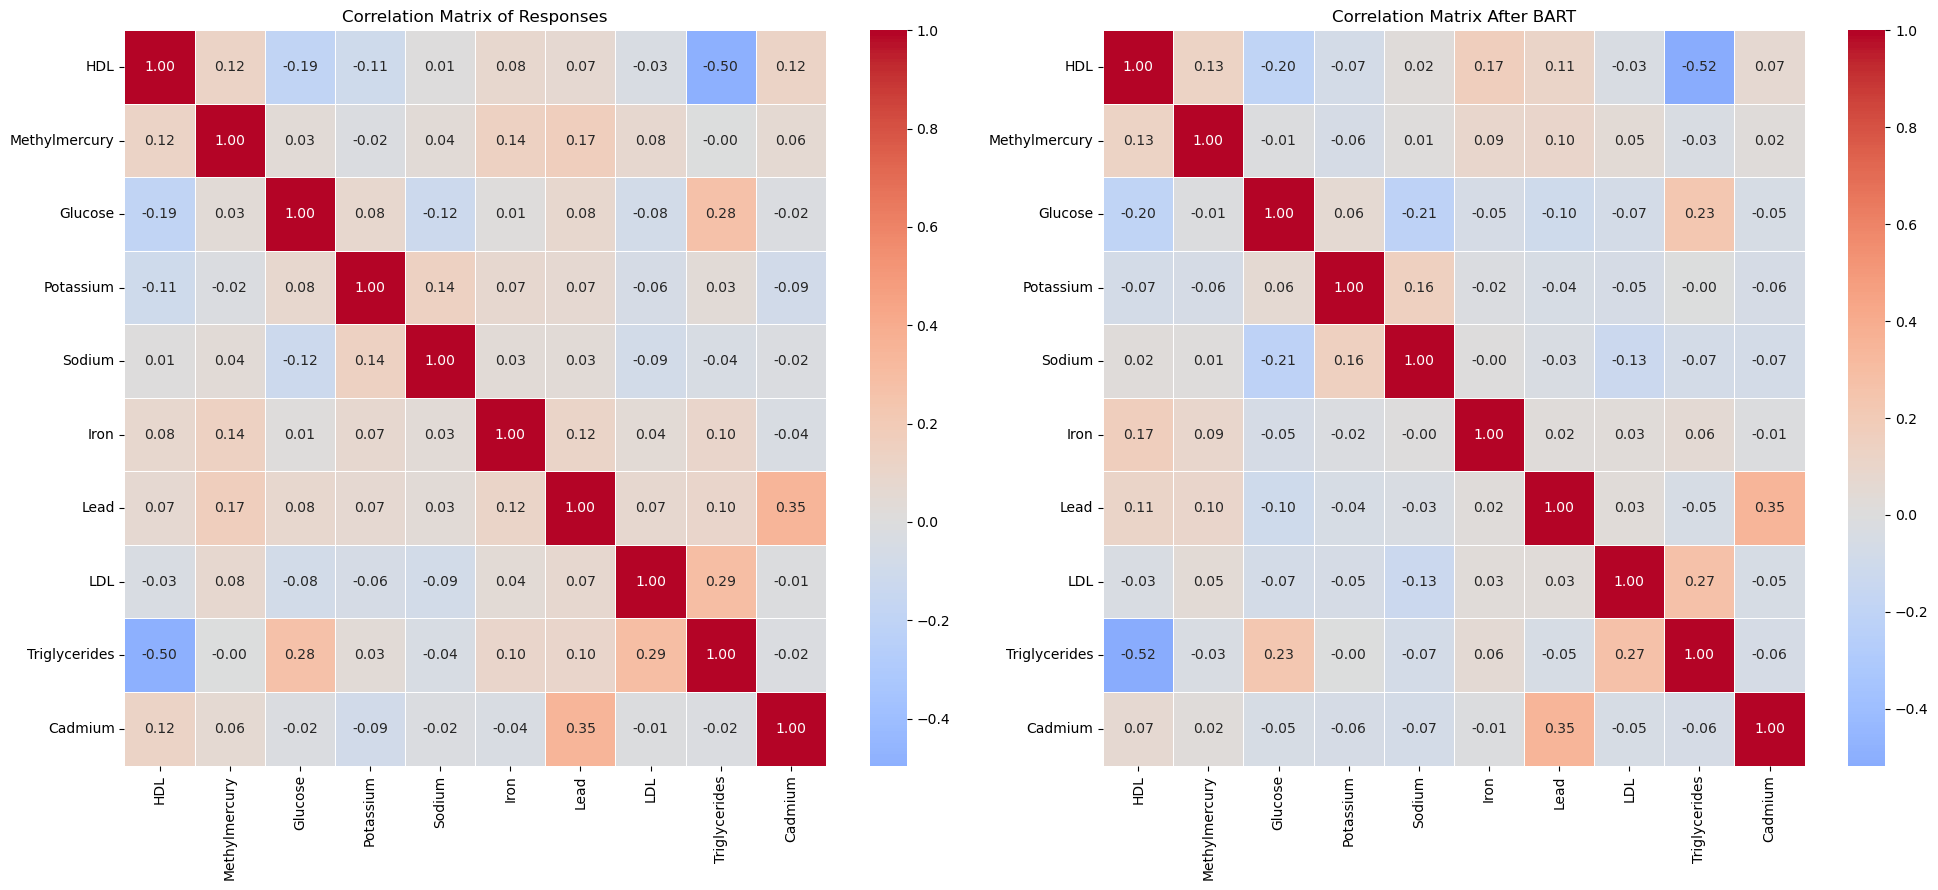

In [12]:
col_names = ['HDL', 'Methylmercury', 'Glucose', 'Potassium', 'Sodium', 'Iron', 'Lead', 'LDL','Triglycerides', 'Cadmium']
corr_matrix_y = pd.DataFrame(y_full_raw).corr()
corr_matrix_y = np.array(corr_matrix_y)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.heatmap(corr_matrix_y, ax=axes[0],
            xticklabels=col_names, yticklabels=col_names,
            cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
axes[0].set_title("Correlation Matrix of Responses")

sns.heatmap(corr_matrix_afterbart, ax=axes[1],
            xticklabels=col_names, yticklabels=col_names,
            cmap='coolwarm', center=0, annot=True, fmt=".2f", linewidths=0.5)
axes[1].set_title("Correlation Matrix After BART")

plt.tight_layout()
plt.show()


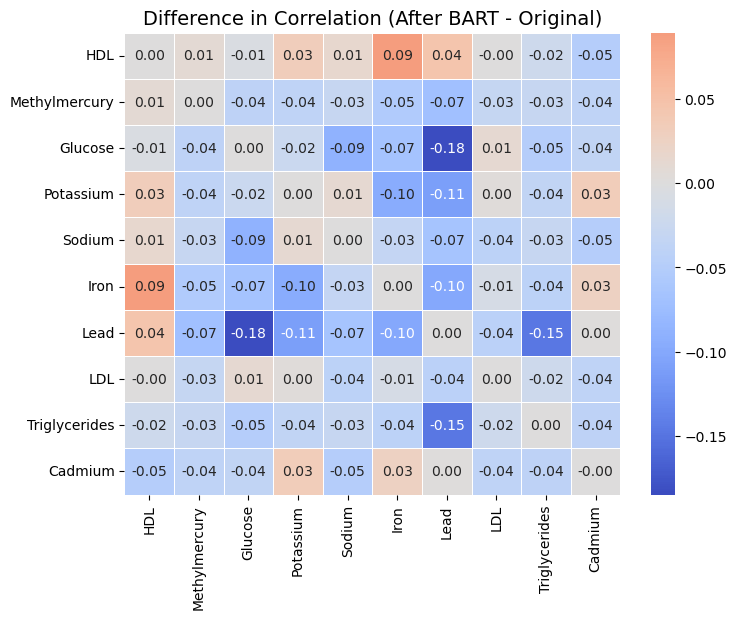

In [13]:
fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(corr_matrix_afterbart - corr_matrix_y,
            ax=ax,
            xticklabels=col_names,
            yticklabels=col_names,
            cmap="coolwarm", center=0,
            annot=True, fmt=".2f",
            linewidths=0.5)

ax.set_title("Difference in Correlation (After BART - Original)", fontsize=14)
plt.show()

### ATE with CI

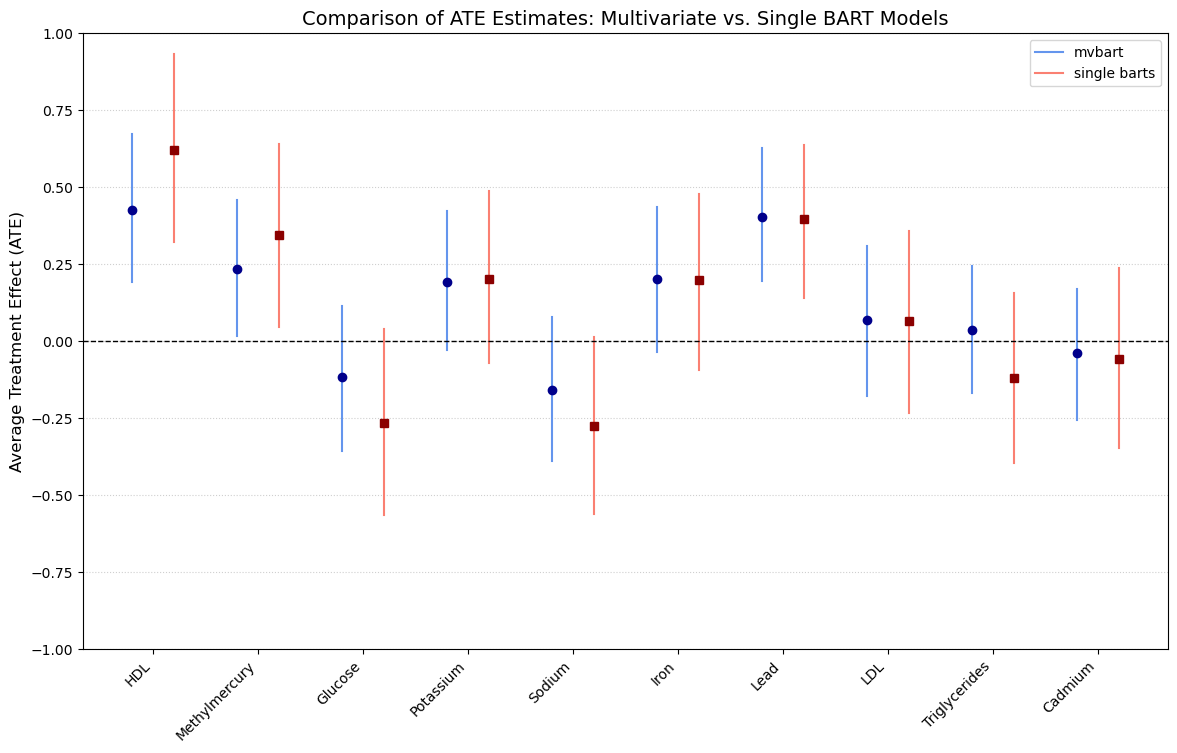

In [14]:
ate_mean_singlebart = [0.6226, 0.3441, -0.2657, 0.2028, -0.2740, 0.1979, 0.3974, 0.0675, -0.1206, -0.0567]
ci_lower_singlebart = [0.3234, 0.0477, -0.5649, -0.0705, -0.5605, -0.0917, 0.1404, -0.2335, -0.3944, -0.3470]
ci_upper_singlebart = [0.9324, 0.6422, 0.0387, 0.4871, 0.0134, 0.4786, 0.6389, 0.3594, 0.1570, 0.2376]

# ate_mean_mvbart = [0.4189, 0.2246, -0.1067, 0.1890, -0.1565, 0.1978, 0.4028, 0.0779, 0.0428, -0.0346]
# ci_lower_mvbart = [0.1712, 0.0059, -0.3526, -0.0430, -0.4022, -0.0349, 0.1840, -0.1584, -0.1570, -0.2453]
# ci_upper_mvbart = [0.6560, 0.4374, 0.1188, 0.4231, 0.0785, 0.4442, 0.6244, 0.3151, 0.2514, 0.1777]

ate_mean_mvbart = jnp.mean(ate_draws, axis=0)
ci_lower_mvbart = jnp.quantile(ate_draws, 0.025, axis = 0)
ci_upper_mvbart = jnp.quantile(ate_draws, 0.975, axis = 0)

# --- Plotting Code ---
plt.figure(figsize=(14, 8)) # Increased figure size for better readability

# Set the positions for the outcomes on the x-axis
x_pos = np.arange(len(ate_mean_mvbart))
# Define the width of the offset for grouping
group_offset = 0.2

# Loop through each outcome to plot both methods' results
for i in range(len(x_pos)):
    # --- Plot Method 1 (mvbart) ---
    # Position for method 1 is slightly to the left
    x1 = x_pos[i] - group_offset
    # Plot CI line (whisker)
    plt.plot([x1, x1], [ci_lower_mvbart[i], ci_upper_mvbart[i]], color='cornflowerblue', linewidth=1.5,
             label='mvbart' if i == 0 else "") # Label only once for the legend
    # Plot the mean estimate as a point
    plt.plot(x1, ate_mean_mvbart[i], 'o', color='darkblue', markersize=6)

    # --- Plot Method 2 (single barts) ---
    # Position for method 2 is slightly to the right
    x2 = x_pos[i] + group_offset
    # Plot CI line (whisker)
    plt.plot([x2, x2], [ci_lower_singlebart[i], ci_upper_singlebart[i]], color='salmon', linewidth=1.5,
             label='single barts' if i == 0 else "") # Label only once for the legend
    # Plot the mean estimate as a point
    plt.plot(x2, ate_mean_singlebart[i], 's', color='darkred', markersize=6) # 's' for square marker


# --- Formatting ---
# Add a horizontal line at y=0 for reference (no effect line)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Set the x-ticks to be in the center of the two groups
plt.xticks(x_pos, outcomes, rotation=45, ha="right")
plt.ylabel("Average Treatment Effect (ATE)", fontsize=12)
plt.ylim(-1.0, 1.0)
plt.title("Comparison of ATE Estimates: Multivariate vs. Single BART Models", fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend() # Display the legend
plt.show()

### RMSE

In [15]:
rmse_per_col

Array([0.93363535, 0.92931604, 0.80586606, 1.0417241 , 0.99467707,
       0.94926333, 0.87263817, 1.0159559 , 0.9909371 , 0.9527142 ],      dtype=float32)

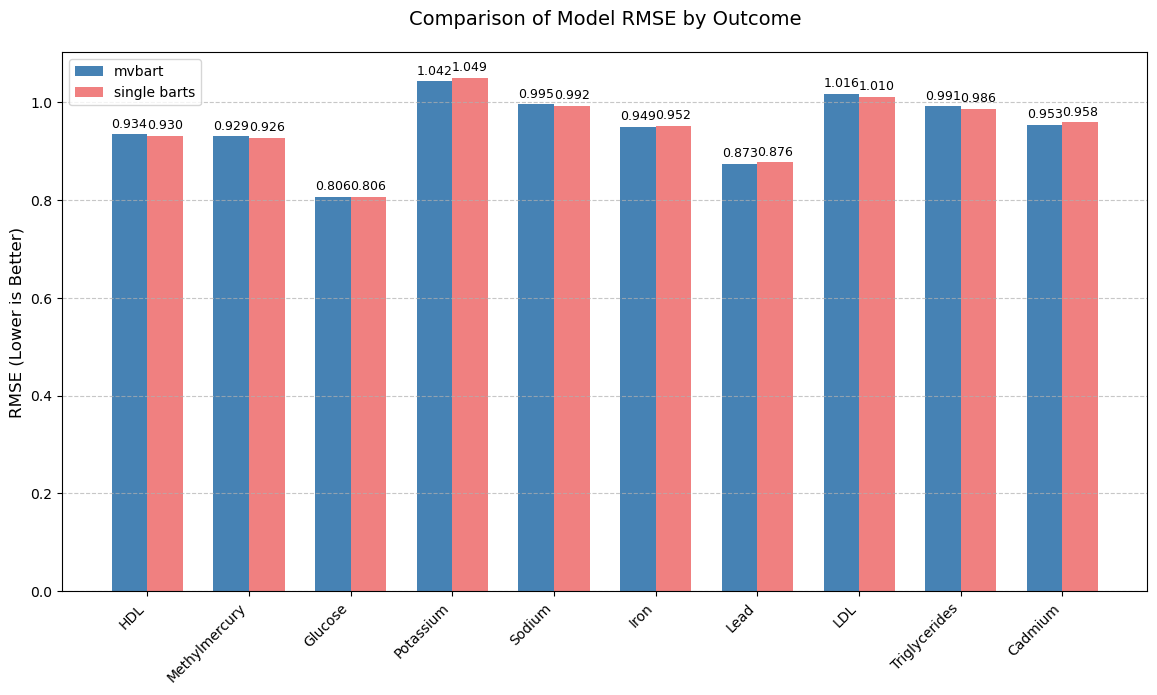

In [16]:
# rmse_values_mvbart = [0.9338, 0.9296, 0.8052, 1.0415, 0.9945, 0.9492, 0.8729, 1.0156, 0.9913, 0.9537]
rmse_values_mvbart = rmse_per_col
rmse_values_singlebart = [0.9299, 0.9261, 0.8061, 1.0488, 0.9922, 0.9517, 0.8762, 1.0100, 0.9857, 0.9584]

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(14, 7))

x_pos = np.arange(len(rmse_values_mvbart))
bar_width = 0.35  # Width of the bars

# Make the plot
rects1 = ax.bar(x_pos - bar_width/2, rmse_values_mvbart, bar_width, label='mvbart', color='steelblue')
rects2 = ax.bar(x_pos + bar_width/2, rmse_values_singlebart, bar_width, label='single barts', color='lightcoral')

# --- Formatting ---

# Add some text for labels, title and axes ticks
ax.set_ylabel('RMSE (Lower is Better)', fontsize=12)
ax.set_title('Comparison of Model RMSE by Outcome', fontsize=14, pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(outcomes, rotation=45, ha="right")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of the bars for clarity
ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=9)
ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=9)

plt.show()

### CATE on age

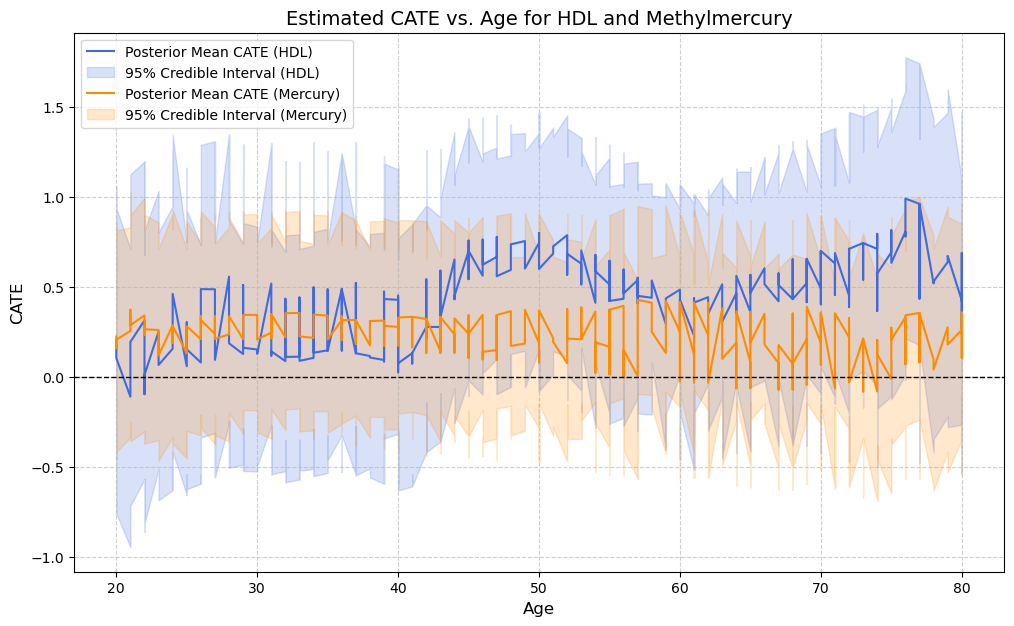

In [17]:
# CATE, age v.s.ate
ate_test_hdl = ate_test[:,:,0]
cate_mean_hdl = jnp.mean(ate_test_hdl, axis=0)
cate_lower_hdl = jnp.quantile(ate_test_hdl, 0.025, axis=0)
cate_upper_hdl = jnp.quantile(ate_test_hdl, 0.975, axis=0)

ate_test_mercury = ate_test[:,:,1]
cate_mean_mercury = jnp.mean(ate_test_mercury, axis=0)
cate_lower_mercury = jnp.quantile(ate_test_mercury, 0.025, axis=0)
cate_upper_mercury = jnp.quantile(ate_test_mercury, 0.975, axis=0)

# Convert to numpy for plotting
age_np = jnp.array(X_test[:,0])
sort_idx = jnp.argsort(age_np)
age_sorted = age_np[sort_idx]

# HDL data
cate_mean_hdl_sorted = jnp.array(cate_mean_hdl)[sort_idx]
cate_lower_hdl_sorted = jnp.array(cate_lower_hdl)[sort_idx]
cate_upper_hdl_sorted = jnp.array(cate_upper_hdl)[sort_idx]

# Mercury data - NEW
cate_mean_mercury_sorted = jnp.array(cate_mean_mercury)[sort_idx]
cate_lower_mercury_sorted = jnp.array(cate_lower_mercury)[sort_idx]
cate_upper_mercury_sorted = jnp.array(cate_upper_mercury)[sort_idx]

plt.figure(figsize=(12, 7))

# Plot for HDL
plt.plot(age_sorted, cate_mean_hdl_sorted, label='Posterior Mean CATE (HDL)', color='royalblue')
plt.fill_between(age_sorted, cate_lower_hdl_sorted, cate_upper_hdl_sorted, color='royalblue', alpha=0.2, label='95% Credible Interval (HDL)')

# Plot for Methylmercury - NEW
plt.plot(age_sorted, cate_mean_mercury_sorted, label='Posterior Mean CATE (Mercury)', color='darkorange')
plt.fill_between(age_sorted, cate_lower_mercury_sorted, cate_upper_mercury_sorted, color='darkorange', alpha=0.2, label='95% Credible Interval (Mercury)')


# Formatting
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Add a zero-effect line
plt.xlabel('Age', fontsize=12)
plt.ylabel('CATE', fontsize=12)
plt.title('Estimated CATE vs. Age for HDL and Methylmercury', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


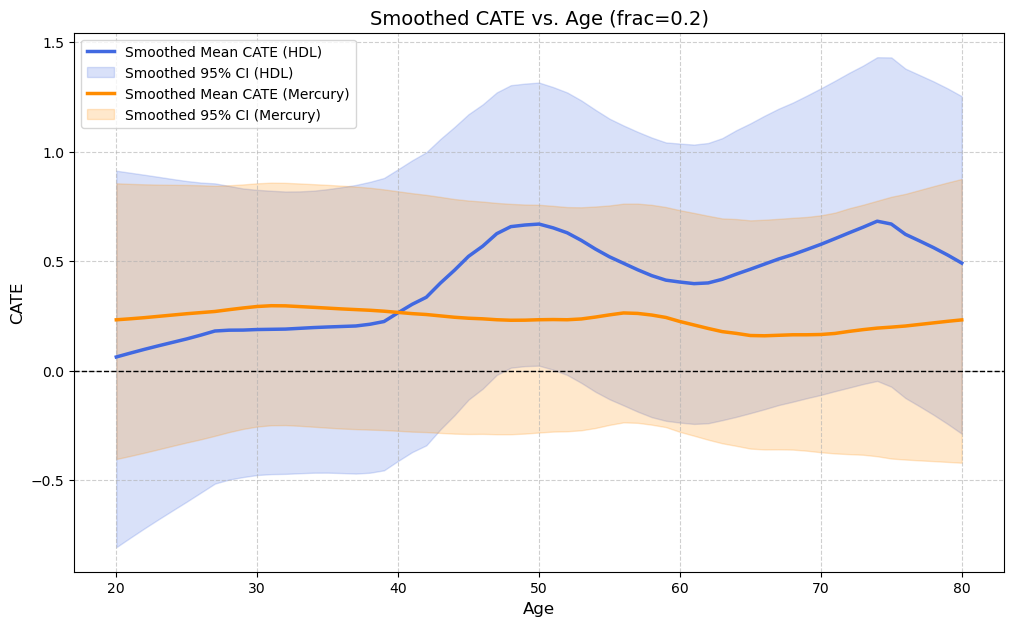

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import statsmodels.api as sm # We'll use this for the smoother

# --- All your previous data processing code remains the same ---
# (I'm omitting it here for brevity, but it's the same as before)
# The result is you have: age_sorted, cate_mean_hdl_sorted,
# cate_lower_hdl_sorted, cate_upper_hdl_sorted, etc.

# --- NEW: Apply the LOWESS smoother ---
# The 'frac' parameter controls the amount of smoothing.
# Higher values (e.g., 0.8) are smoother, lower values (e.g., 0.2) are more jagged.
# 0.5 is often a good starting point.
frac_smooth = 0.2

# Smooth the HDL data
smooth_hdl = sm.nonparametric.lowess(cate_mean_hdl_sorted, age_sorted, frac=frac_smooth)
smooth_hdl_lower = sm.nonparametric.lowess(cate_lower_hdl_sorted, age_sorted, frac=frac_smooth)
smooth_hdl_upper = sm.nonparametric.lowess(cate_upper_hdl_sorted, age_sorted, frac=frac_smooth)

# Smooth the Mercury data
smooth_mercury = sm.nonparametric.lowess(cate_mean_mercury_sorted, age_sorted, frac=frac_smooth)
smooth_mercury_lower = sm.nonparametric.lowess(cate_lower_mercury_sorted, age_sorted, frac=frac_smooth)
smooth_mercury_upper = sm.nonparametric.lowess(cate_upper_mercury_sorted, age_sorted, frac=frac_smooth)


# --- Plot the SMOOTHED results ---
plt.figure(figsize=(12, 7))

# Plot for HDL
# The lowess function returns two columns (x, y), so we plot them
plt.plot(smooth_hdl[:, 0], smooth_hdl[:, 1], label='Smoothed Mean CATE (HDL)', color='royalblue', linewidth=2.5)
plt.fill_between(smooth_hdl_lower[:, 0], smooth_hdl_lower[:, 1], smooth_hdl_upper[:, 1], color='royalblue', alpha=0.2, label='Smoothed 95% CI (HDL)')

# Plot for Methylmercury
plt.plot(smooth_mercury[:, 0], smooth_mercury[:, 1], label='Smoothed Mean CATE (Mercury)', color='darkorange', linewidth=2.5)
plt.fill_between(smooth_mercury_lower[:, 0], smooth_mercury_lower[:, 1], smooth_mercury_upper[:, 1], color='darkorange', alpha=0.2, label='Smoothed 95% CI (Mercury)')


# Formatting
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Age', fontsize=12)
plt.ylabel('CATE', fontsize=12)
# plt.title(f'Smoothed CATE vs. Age (frac={frac_smooth})', fontsize=14)
plt.title(f'Smoothed CATE vs. Age', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()